<a href="https://colab.research.google.com/github/Changse11/AI/blob/main/Algoritma%20Naive%20Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Algoritma Bernoulli Naive Bayes**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
# Load dataset
data = pd.read_csv('bots_vs_users.csv')

In [ ]:
# Ambil kolom fitur biner
fitur_biner = [col for col in data.columns if col.startswith(('has_', 'is_', 'can_'))]

In [ ]:
# Preprocessing data (Mengubah Unknown menjadi 0)
fitur = data[fitur_biner].replace('Unknown', 0).astype(float).astype(int)
label = data['target']

In [ ]:
# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    fitur, label, test_size=0.2, random_state=41
)

In [ ]:
# Inisialisasi model Bernoulli Naive Bayes
bnb_model = BernoulliNB()
bnb_model.fit(X_train, y_train)

BernoulliNB()

In [ ]:
# Prediksi
prediksi = bnb_model.predict(X_test)

In [ ]:
# Evaluasi akurasi
print(f"Akurasi Bernoulli NB: {accuracy_score(y_test, prediksi)*100:.2f}%")

print("\n--- Laporan Klasifikasi Bots vs Users ---")
print(classification_report(y_test, prediksi))

Akurasi Bernoulli NB: 90.72%

--- Laporan Klasifikasi Bots vs Users ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       567
           1       0.94      0.88      0.91       608

    accuracy                           0.91      1175
   macro avg       0.91      0.91      0.91      1175
weighted avg       0.91      0.91      0.91      1175



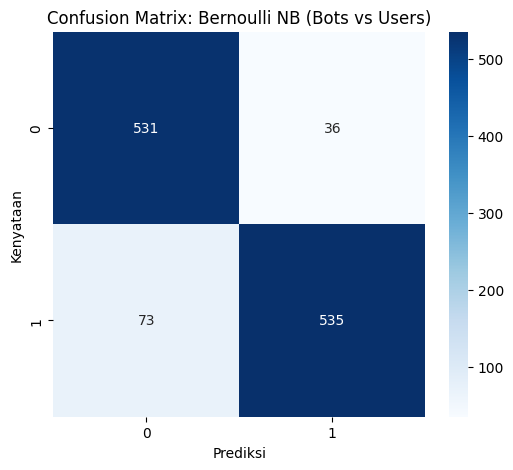

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, prediksi)

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=bnb_model.classes_,
            yticklabels=bnb_model.classes_)

plt.title('Confusion Matrix: Bernoulli NB (Bots vs Users)')
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.show()

**Algortima Categorical Naive Bayes**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load dataset
data = pd.read_csv('nursery.csv')

In [ ]:
# Pisahkan fitur dan label
fitur = data.drop('final evaluation', axis=1)
label = data['final evaluation']

In [ ]:
# Preprocessing data (mengubah kategori menjadi angka)
encoder = LabelEncoder()

for col in fitur.columns:
    fitur[col] = encoder.fit_transform(fitur[col])

label = encoder.fit_transform(label)

In [ ]:
# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    fitur, label, test_size=0.2, random_state=41
)

In [ ]:
# Inisialisasi model Categorical Naive Bayes
cnb_model = CategoricalNB()
cnb_model.fit(X_train, y_train)

CategoricalNB()

In [ ]:
# Prediksi
prediksi = cnb_model.predict(X_test)

In [ ]:
# Evaluasi akurasi
print(f"Akurasi Categorical NB: {accuracy_score(y_test, prediksi)*100:.2f}%")

print("\n--- Laporan Klasifikasi Nursery Dataset ---")
print(classification_report(y_test, prediksi))

Akurasi Categorical NB: 90.51%

--- Laporan Klasifikasi Nursery Dataset ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       849
           1       0.83      0.90      0.86       854
           3       0.89      0.88      0.89       825
           4       1.00      0.09      0.17        64

    accuracy                           0.91      2592
   macro avg       0.93      0.72      0.73      2592
weighted avg       0.91      0.91      0.90      2592



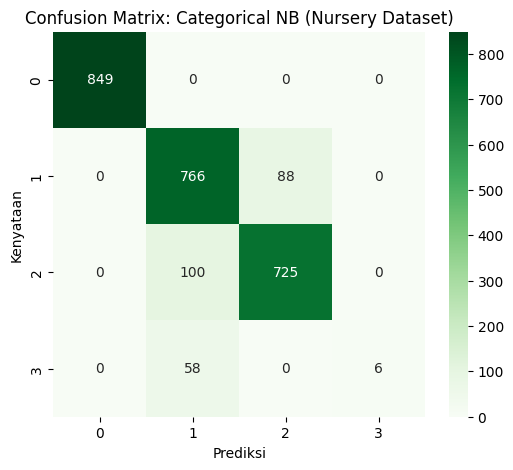

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, prediksi)

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')

plt.title('Confusion Matrix: Categorical NB (Nursery Dataset)')
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.show()